In [867]:
import scipy
from scipy.stats import skewnorm
from scipy.stats import lognorm
import matplotlib.pyplot as plt
import numpy as np
import csv
import time
import pandas as pd
import varray as va
import ldax_processing as ldax
from datetime import datetime
from scipy.optimize import curve_fit, minimize
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [381]:
# load latest RQ file without amplification
data_lib = '/Users/bfeike/Documents/TPC_RQs'
raw_lib = '/Users/bfeike/Documents/TPC_data'
d = va.load(f'{data_lib}/2026-01-23-1155_RQ.vrz')
# load cobalt and barium RQ files with amplification
d0 = va.load(f'{data_lib}/2026-03-09-1556_000000_RQ.vrz')
d1 = va.load(f'{data_lib}/2026-03-09-1556_000001_RQ.vrz')
d_ba = va.load(f'{data_lib}/2026-02-11-0841_000000_RQ.vrz')

d0_raw = f'{raw_lib}/2026-03-09-1556_000000.bin.gz'
d1_raw = f'{raw_lib}/2026-03-09-1556_000001.bin.gz'

ds_raw = [d0_raw, d1_raw]

ds = [d0, d1]
d_co = {}
for k in d0.keys():
  if type(d0[k]) is int:
    d_co[k] = d0[k]
  elif type(d0[k]) is str:
    d_co[k] = d0[k]
  elif type(d0[k]) is np.ndarray:
    d_co[k] = np.append(d0[k], d1[k])
  else:
    dlist = list((d0[k], d1[k]))
    d_co[k] = va.row_concat(dlist)

In [385]:
print(len(d_co['p_area']))

100000


In [1091]:
ch_arr = np.arange(32)
p_area_co = []
p_height_co = []
p_width_co = []
p_mean_area_co = []
p_mean_height_co = []
eventid_arr_co = []
pulseid_arr_co = []
see_area_co = []
see_height_co = []
see_width_co = []
see_eventid_co = []
see_pulseid_co = []

cut_s2 = d_co['p_class'] == 2

# Calculate all channel pulse areas and heights with cut applied:

p_area_co = d_co['p_area'][cut_s2].flatten()
p_height_co = d_co['p_height'][cut_s2].flatten()
p_width_co = d_co['p_width_1090'][cut_s2].flatten()
p_eventid_co = d_co['p_area'].get_row_index()[cut_s2].flatten()
p_pulseid_co = d_co['p_area'].get_col_index()[cut_s2].flatten()

cut_see = ((p_width_co/p_height_co) < 0.1) & (p_area_co > 50000) & (p_area_co < 90000)

see_area_co = p_area_co[cut_see]
see_height_co = p_height_co[cut_see]
see_width_co = p_width_co[cut_see]
see_eventid_co = p_eventid_co[cut_see]
see_pulseid_co = p_pulseid_co[cut_see]
        
p_mean_area_co = np.mean(p_area_co)
p_mean_height_co = np.mean(p_height_co)

In [4]:
ch_arr = np.arange(32)
all_ch_area_ba = []
all_ch_height_ba = []
all_ch_eventids_ba = []
all_ch_pulseids_ba = []
see_area_ba = []
see_height_ba = []
see_mean_area_ba = []
see_mean_height_ba = []
ch_area = []
ch_eventid_arr = []
ch_pulseid_arr = []
ch_height = []

#cut_see = d_co['p_class'] == 2

# Calculate all channel pulse areas and heights with cut applied:

for ch in ch_arr:
    ch_area = d_ba['p_area_ch'][:,ch,:].flatten()
    ch_height = d_ba['p_height_ch'][:,ch,:].flatten()
    ch_eventid_arr = d_ba['p_area_ch'].get_row_index()[:,ch,:].flatten()
    ch_pulseid_arr = d_ba['p_area_ch'].get_col_index()[:,ch,:].flatten()
    
    cut_see2 = ((ch_area/ch_height) > 25) & (ch_area > 0)
    
    ch_see_area = ch_area[cut_see2]
    ch_see_height = ch_height[cut_see2]
    ch_see_mean_area = np.mean(ch_see_area)
    ch_see_mean_height = np.mean(ch_see_height)

    all_ch_area_ba.append(ch_area)
    all_ch_height_ba.append(ch_height)
    all_ch_eventids_ba.append(ch_eventid_arr)
    all_ch_pulseids_ba.append(ch_pulseid_arr)
    see_area_ba.append(ch_see_area)
    see_height_ba.append(ch_see_height)
    see_mean_area_ba.append(ch_see_mean_area)
    see_mean_height_ba.append(ch_see_mean_height)

/var/folders/38/3hjm2p6d105_6f12ftzm_pfm0000gn/T/ipykernel_5254/2330519083.py:25: RuntimeWarning: divide by zero encountered in divide
  cut_see2 = ((ch_area/ch_height) > 25) & (ch_area > 0)
/var/folders/38/3hjm2p6d105_6f12ftzm_pfm0000gn/T/ipykernel_5254/2330519083.py:25: RuntimeWarning: invalid value encountered in divide
  cut_see2 = ((ch_area/ch_height) > 25) & (ch_area > 0)


In [541]:
# Error of the mean estimation (Poisson statistics)
def mu_err(see_area, see_height, ch_arr):
    sigma_area_arr = []
    sigma_height_arr = []
    stmean_area_arr = []
    stmean_height_arr = []
    
    for ch in ch_arr:
        n = len(see_area)
        sigma_area_arr.append(np.std(see_area[ch]))
        sigma_height_arr.append(np.std(see_height[ch]))
        stmean_area_arr.append(np.std(see_area[ch])/np.sqrt(n))
        stmean_height_arr.append(np.std(see_height[ch])/np.sqrt(n))
        
    return sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr

In [542]:
sigma_area_co, sigma_height_co, stmean_area_co, stmean_height_co = mu_err(see_area_co, see_height_co, ch_arr)

In [1127]:
# Fit functions
def Gaussian(x, peak, sigma, mu):
    return(peak*(1/(sigma*np.sqrt(2*np.pi)))*np.exp((-(x-mu)**2/(2*sigma**2))))

def logGaussian(x, w1, s1, mean1):
    return(w1*lognorm.pdf(x, s1, scale=mean1, loc=0))

def logtwoGaussian(x, w1, s1, mean1, w2, s2, mean2):
    pdf1 = lognorm.pdf(x, s1, scale=mean1)
    pdf2 = lognorm.pdf(x, s2, scale=mean2)
    return (w1*pdf1)+((w2)*pdf2)

def gaussfit(el, sigma_area, ch_arr, pres_arr=None):
    if el == 0:
        see_area_el = p_area_co
    elif el == 1:
        see_area_el = see_area_ba
    elif el == 2:
        see_area_el = p_area_co
        pres = np.zeros(32,3)
        prescov = np.zeros(3,3)
        fig, axs = plt.subplots(nrows=16, ncols=2);
        start = np.log10(min(see_area_co))
        stop = np.log10(max(see_area_co))
        binslog = 10 ** np.linspace(start, stop, 200)
        counts, bins, patches = axs.hist(see_area_co, edgecolor='black', bins=binslog)
        bins = (bins[:-1]+bins[1:])/2
        counts = [float(n)/max(counts) for n in counts]
        data = np.random.normal(pres_arr[2], pres_arr[1], 30000)
        nucounts, nubins, nupatches = axs.hist(data, edgecolor='black', bins=150, range=[30,500], alpha=0);
        plt.close()
        nucounts = [float(k)/max(nucounts) for k in nucounts]
        diff = np.array(counts) - np.array(nucounts)
        popt, pcov = curve_fit(logGaussian,xdata=bins,ydata=diff,p0=(10,30,5000000),sigma=sigma_area[0],bounds=([None,None,None],[None,None,None]),maxfev=100000)
        pres = popt
        prescov = pcov
        err_mean_area = pcov[2,2]

        return pres, prescov, err_mean_area
    
    pres = np.zeros((3))
    prescov = np.zeros((3,3))
    fig, axs = plt.subplots(nrows=1, ncols=1);
    #start = np.log10(min(see_area_el))
    #stop = np.log10(max(see_area_el))
    #binslog = 10 ** np.linspace(start, stop, 200)
    counts, bins, patches = axs.hist(see_area_el, bins=100, range=[50000,90000]);
    plt.close()
    bins = (bins[:-1]+bins[1:])/2
    popt, pcov = curve_fit(Gaussian,xdata=bins,ydata=counts,p0=(300000, 10000, 7e4),sigma=sigma_area[ch],bounds=([None,None,None],[None,None,None]),maxfev=100000)
    pres = popt
    prescov = pcov
    err_mean_area = pcov[2,2]
        
    return pres, prescov, err_mean_area

def twogaussfit(el, sigma_area, ch_arr):
    if el == 0:
        see_area_el = see_area_co
    elif el == 1:
        see_area_el = see_area_ba
    pres = np.zeros((6))
    prescov = np.zeros((6,6))
    err_mean_area = np.zeros(2)
    fig, axs = plt.subplots(nrows=1, ncols=1);
    start = np.log10(min(see_area_el))
    stop = np.log10(max(see_area_el))
    binslog = 10 ** np.linspace(start, stop, 200)
    counts, bins, patches = axs.hist(see_area_el, bins=binslog)
    plt.close()
    bins = (bins[:-1]+bins[1:])/2
    popt, pcov = curve_fit(logtwoGaussian,xdata=bins,ydata=counts,p0=(3.5e9, 0.3, 2.3e6, 1e9, 0.1, 4e6),sigma=sigma_area[0],bounds=([None,None,None,None,None,None],[None,None,None,None,None,None]),maxfev=100000)
    pres = popt
    prescov = pcov
    err_mean_area = [pcov[2,2], pcov[4,4]]
        
    return pres, prescov, err_mean_area

In [1124]:
pres_co, prescov_co, err_mean_area_co = gaussfit(0, sigma_area_co, ch_arr)
print(pres_co)

[300000.  10000.  70000.]


/var/folders/38/3hjm2p6d105_6f12ftzm_pfm0000gn/T/ipykernel_5254/3335517297.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(Gaussian,xdata=bins,ydata=counts,p0=(300000, 10000, 7e4),sigma=sigma_area[ch],bounds=([None,None,None],[None,None,None]),maxfev=100000)


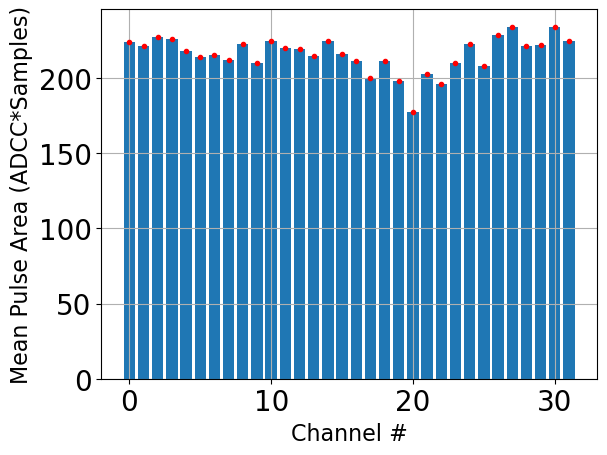

IndexError: invalid index to scalar variable.

In [825]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(ch_arr, diff_co[:,2])
plt.errorbar(ch_arr, diff_co[:,2], yerr=np.sqrt(err_mean_area_co), color='r', fmt='.')
plt.grid()
plt.xlabel('Channel #', fontsize=16)
plt.ylabel('Mean Pulse Area (ADCC*Samples)', fontsize=16)
plt.show()
for ch in ch_arr:
    print(f'Channel {ch}: {diff_co[ch,2]:.5g} +/- {np.sqrt(err_mean_area_co[ch]):.3g}')

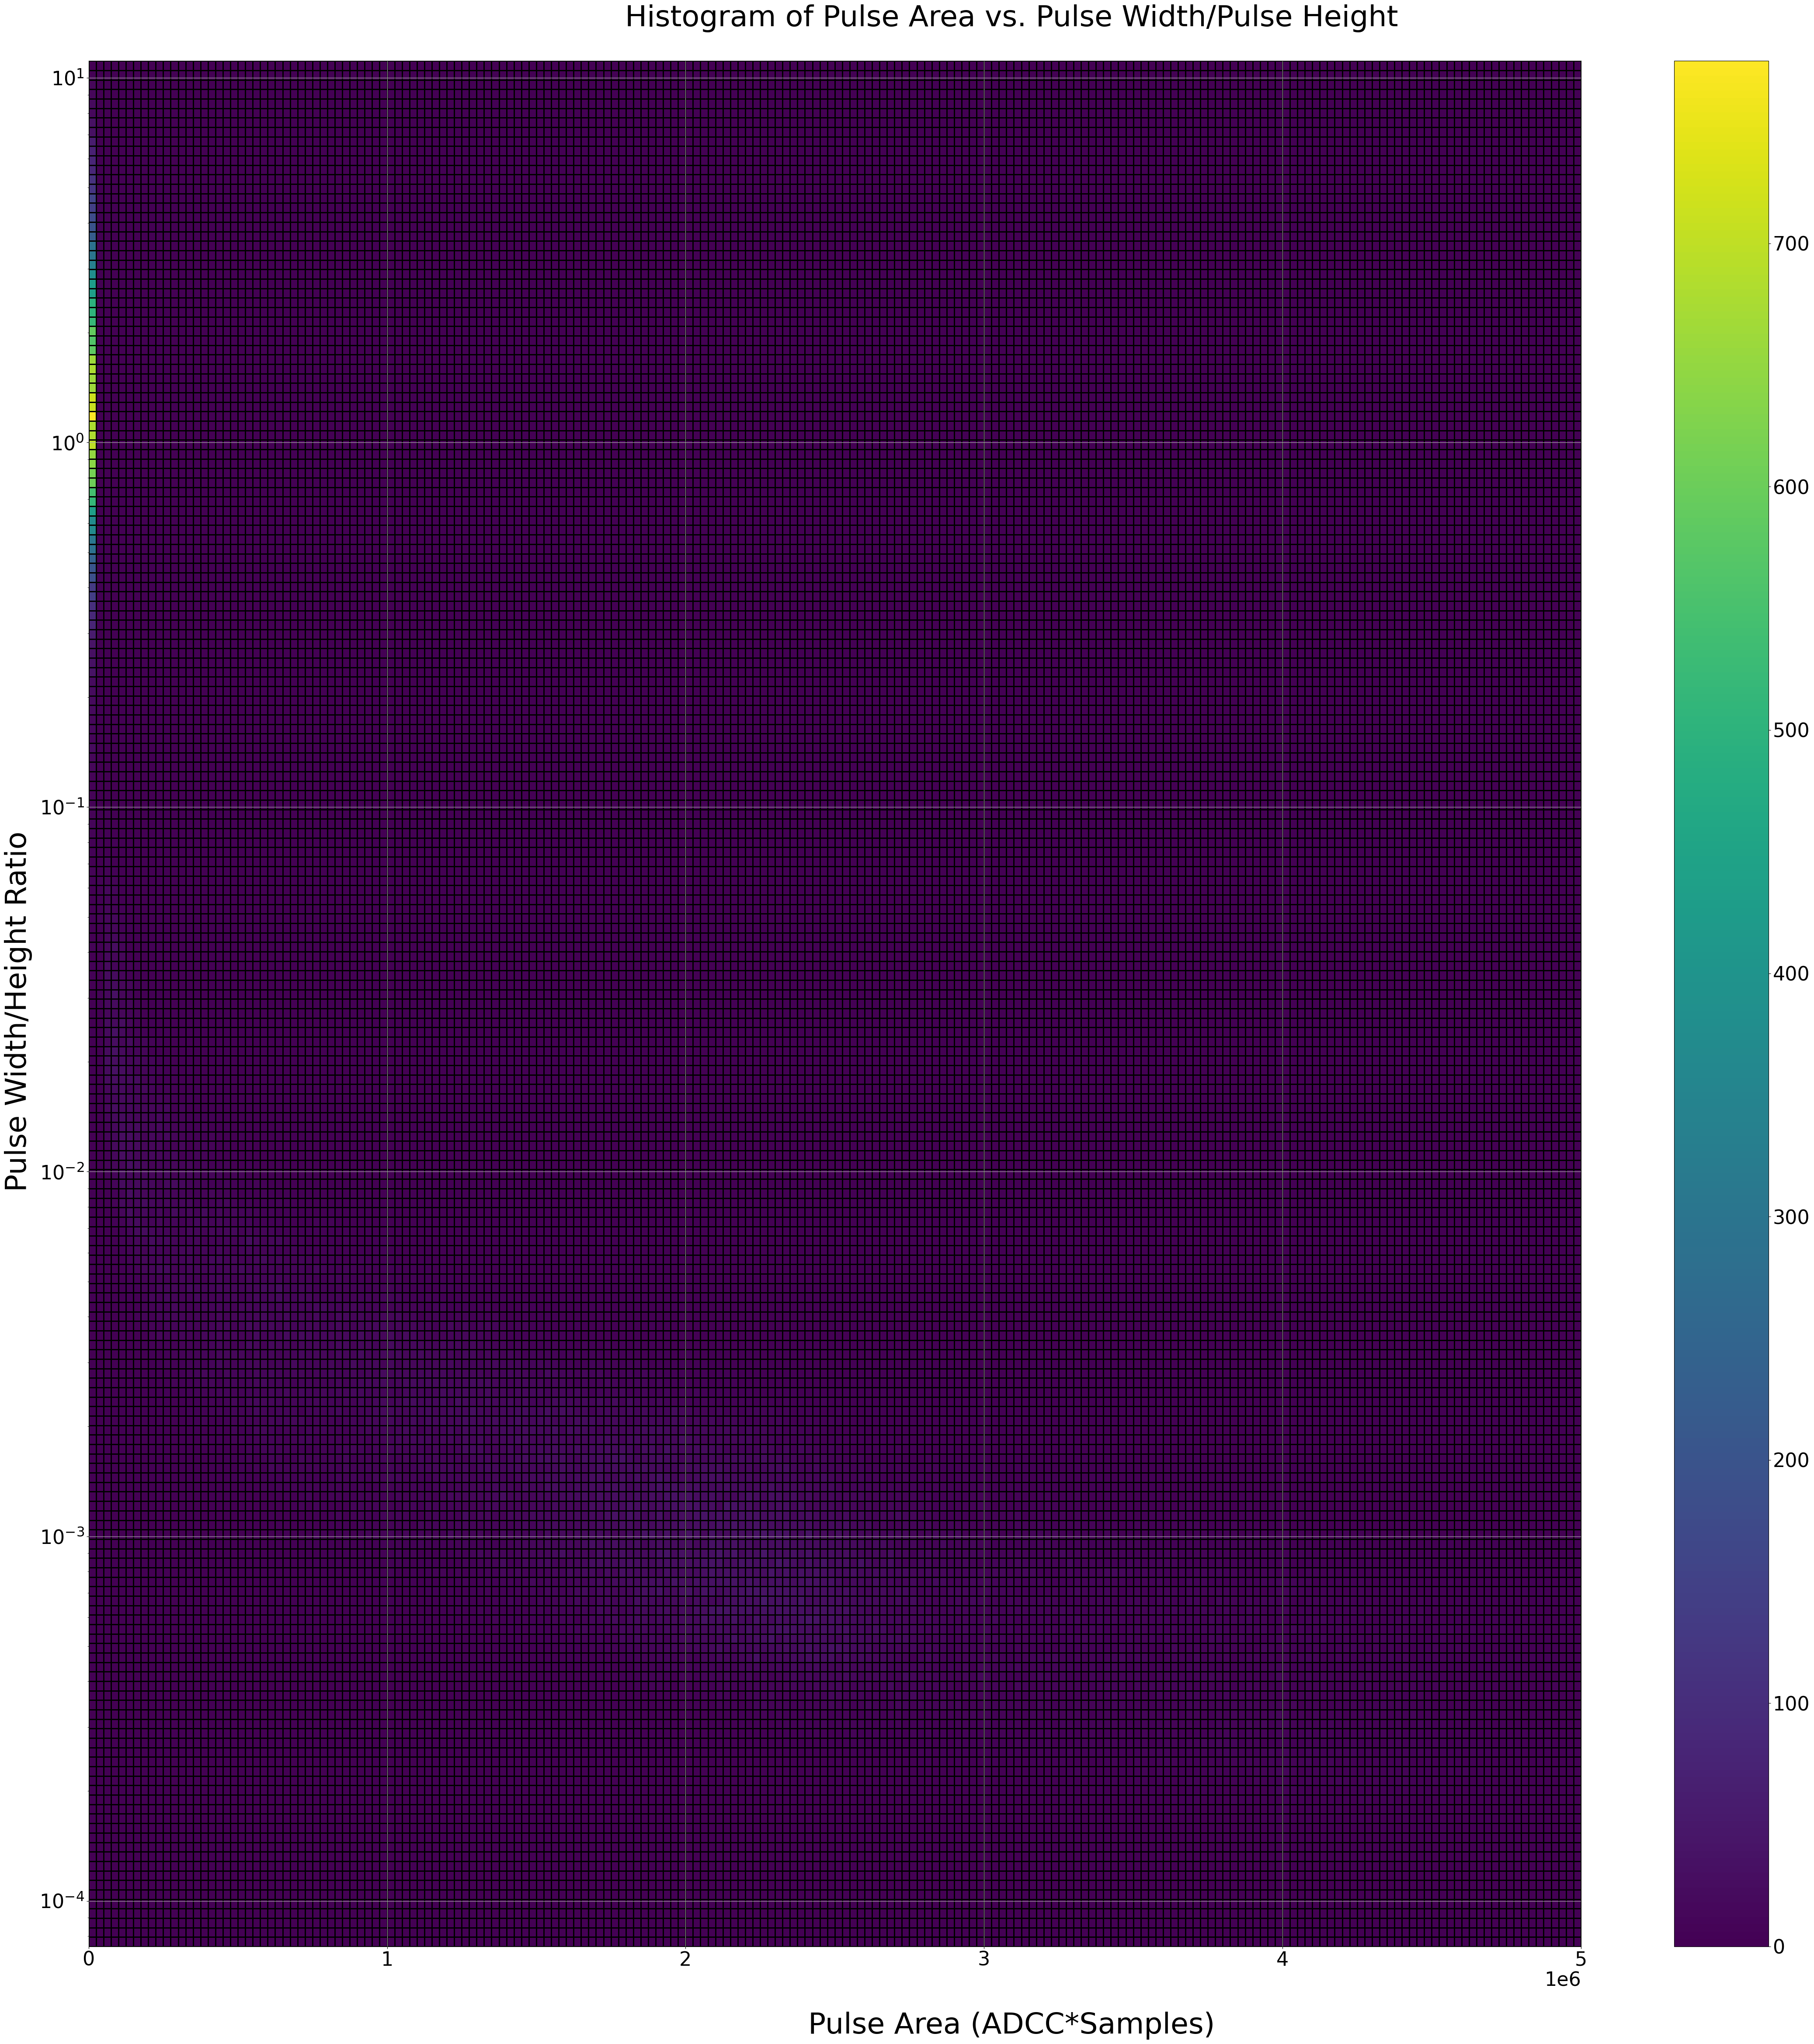

In [571]:
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(48,48))
plt.tight_layout(pad=15, h_pad=None, w_pad=None, rect=None)
start = np.log10(min(p_width_co/p_height_co))
stop = np.log10(max(p_width_co/p_height_co))
binslog = 10 ** np.linspace(start, stop, 200)
counts, xedges, yedges, im1 = axs.hist2d(p_area_co, p_width_co/p_height_co, edgecolor='black', bins=[200,binslog], range=[[0,5000000],[0,100]])
axs.set_yscale('log')
axs.grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=48)
fig.supylabel('Pulse Width/Height Ratio', fontsize=48)
fig.colorbar(im1)
fig.suptitle('Histogram of Pulse Area vs. Pulse Width/Pulse Height', fontsize=48)
plt.show()

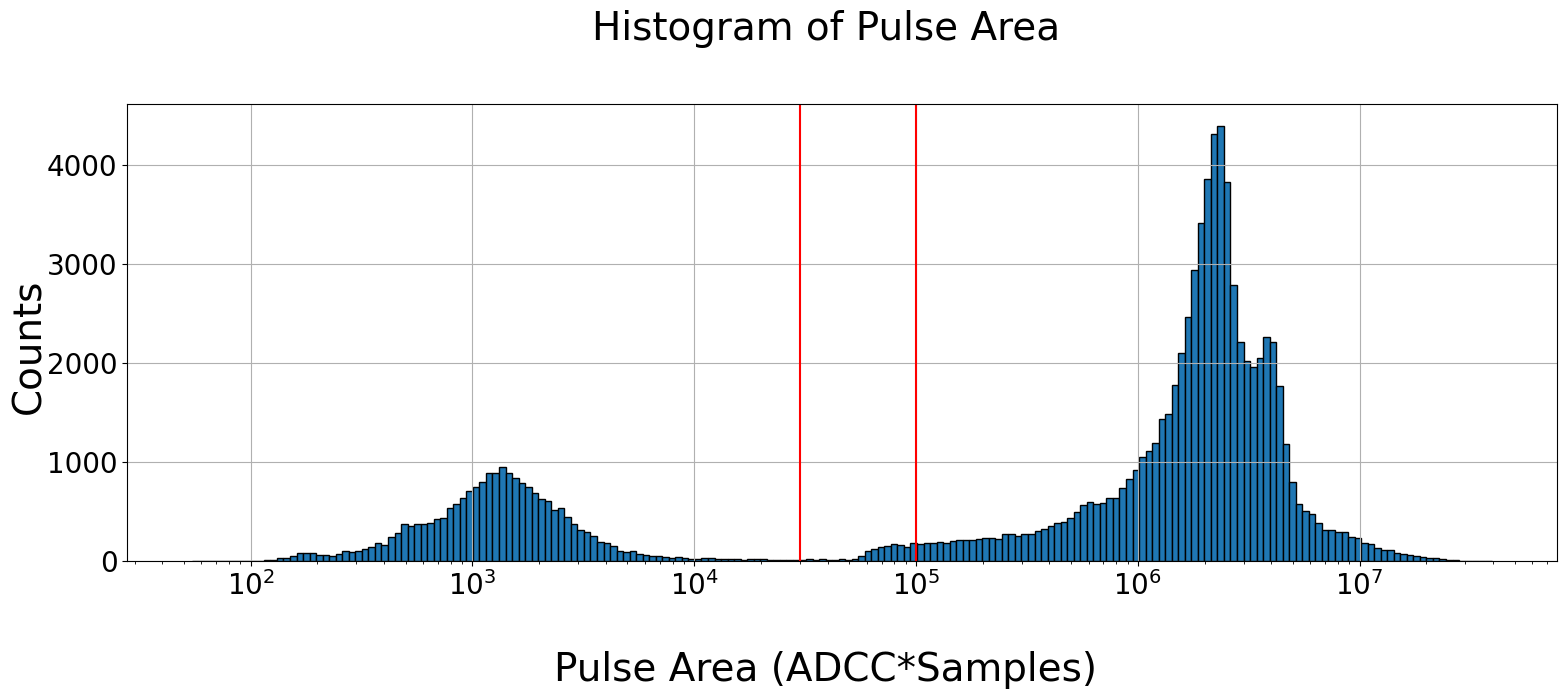

In [1093]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(17, 7))
plt.tight_layout(pad=7, h_pad=None, w_pad=None, rect=None)
start = np.log10(min(p_area_co))
stop = np.log10(max(p_area_co))
binslog = 10 ** np.linspace(start, stop, 200)
axs.hist(p_area_co, edgecolor='black', bins=binslog, range=[0,100000])
axs.set_xscale('log')
axs.axvline(x=30000, color='r')
axs.axvline(x=100000, color='r')
axs.grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=28)
fig.supylabel('Counts', fontsize=28)
fig.suptitle('Histogram of Pulse Area', fontsize=28)
plt.show()

cut_eventids = []
cut_pulseids = []

cut_box = (p_area_co>30000)&(p_area_co<50000)
cut_eventids = p_eventid_co[cut_box]
cut_pulseids = p_pulseid_co[cut_box]

In [1106]:
print(max(Gaussian(bins, 30000, 1000, 7e4)))

11.731280819263677


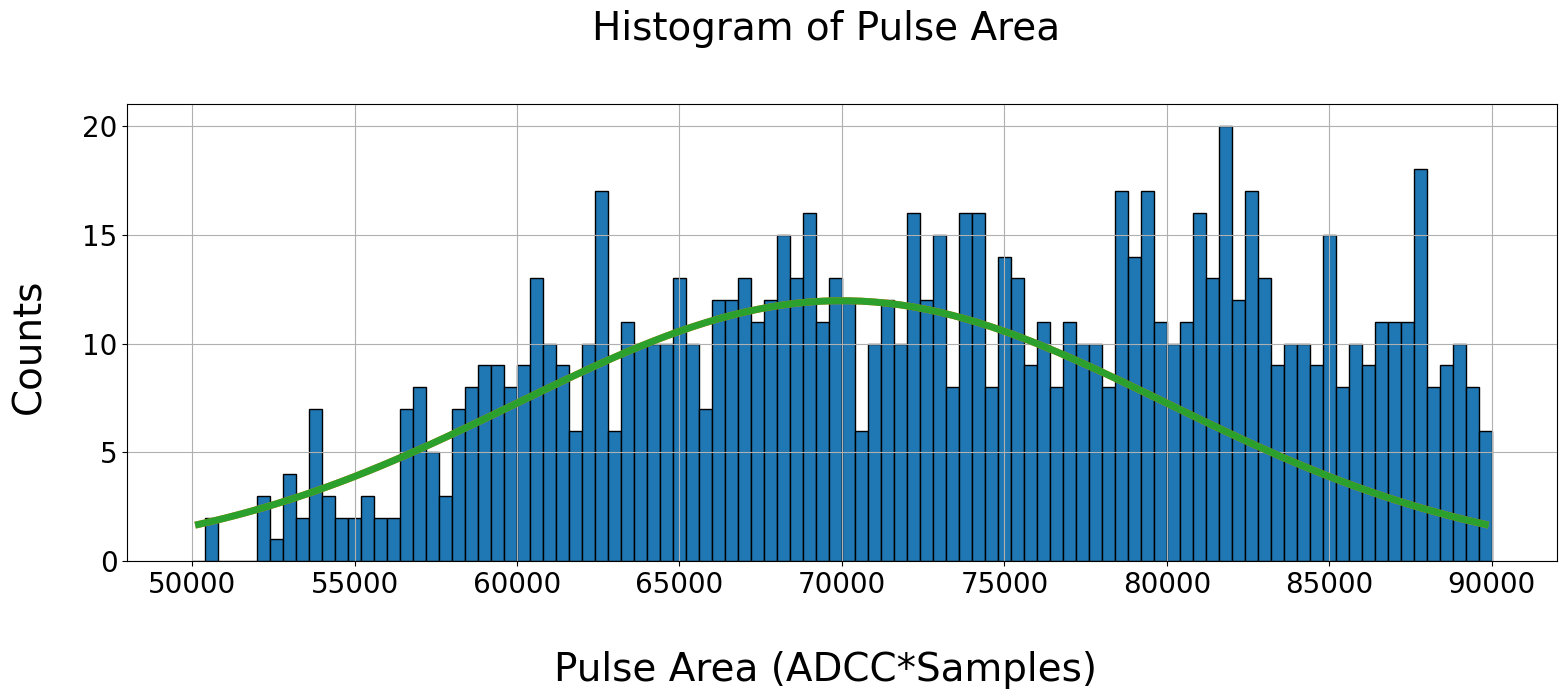

In [1125]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(17, 7))
plt.tight_layout(pad=7, h_pad=None, w_pad=None, rect=None)
start = np.log10(min(see_area_co))
stop = np.log10(max(see_area_co))
binslog = 10 ** np.linspace(start, stop, 200)
counts, bins, patches = axs.hist(see_area_co, edgecolor='black', bins=100, range=[50000,90000]);
bins = (bins[:-1]+bins[1:])/2
axs.plot(bins, Gaussian(bins, pres_co[0], pres_co[1], pres_co[2]), lw=5)
axs.plot(bins, Gaussian(bins, 300000, 10000, 7e4), lw=5)
axs.grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=28)
fig.supylabel('Counts', fontsize=28)
fig.suptitle('Histogram of Pulse Area', fontsize=28)
plt.show()

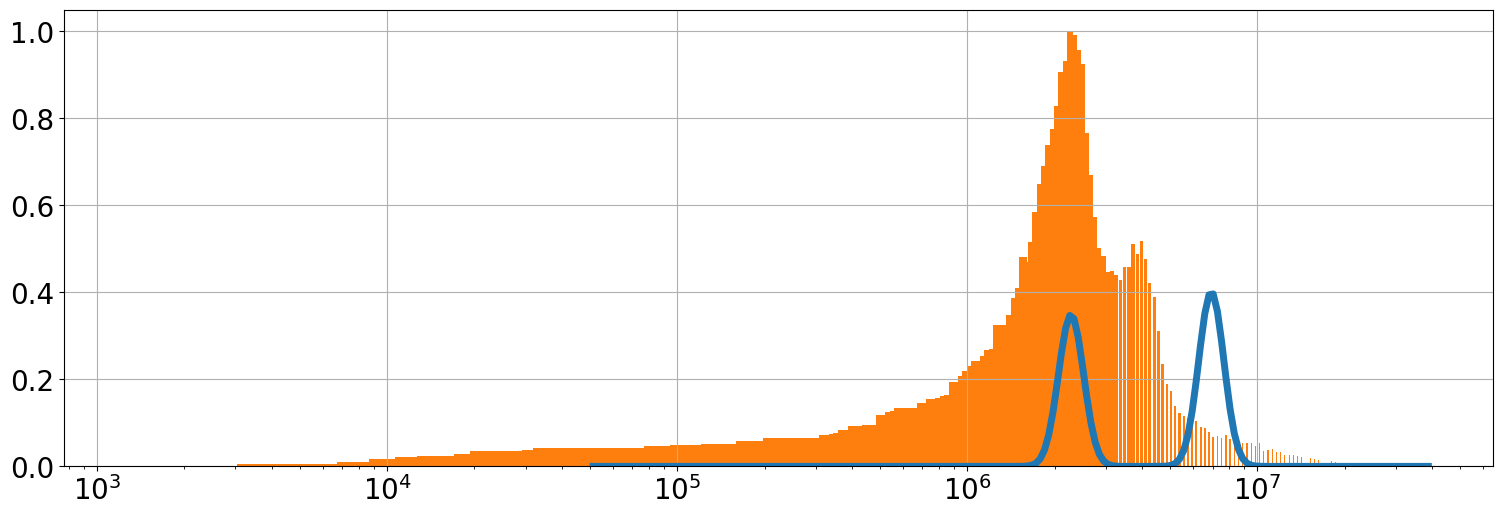

In [1016]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(17, 7))
plt.tight_layout(pad=7, h_pad=None, w_pad=None, rect=None)
nucounts = [float(n)/max(counts) for n in counts]
axs.bar(bins, nucounts, width=100000, color='C1')
axs.plot(bins, logtwoGaussian(bins, 2e5, 0.1, 2.3e6, 7e5, 0.1, 7e6), lw=5)
#axs.plot(bins, logtwoGaussian(bins, pres_co[0], pres_co[1], pres_co[2], pres_co[3], pres_co[4], pres_co[5]), lw=5, color='r')
axs.set_xscale('log')
axs.grid()
plt.show()

In [383]:
waveforms_co, wav_info, header = ldax.Read_DDC40_fName(ds_raw[0])
print(waveforms_co.shape)

(50000, 32, 2048)


In [496]:
print(d_co['p_bnds'][132])
print(d_co['p_bnds'][132][:,2])
print(d_co['p_area'][132])

[[ 833 1064 1186]
 [1063 1163 2015]]
[1186 2015]
[2215946.03032326   -9688.01842757  -82191.46615823]


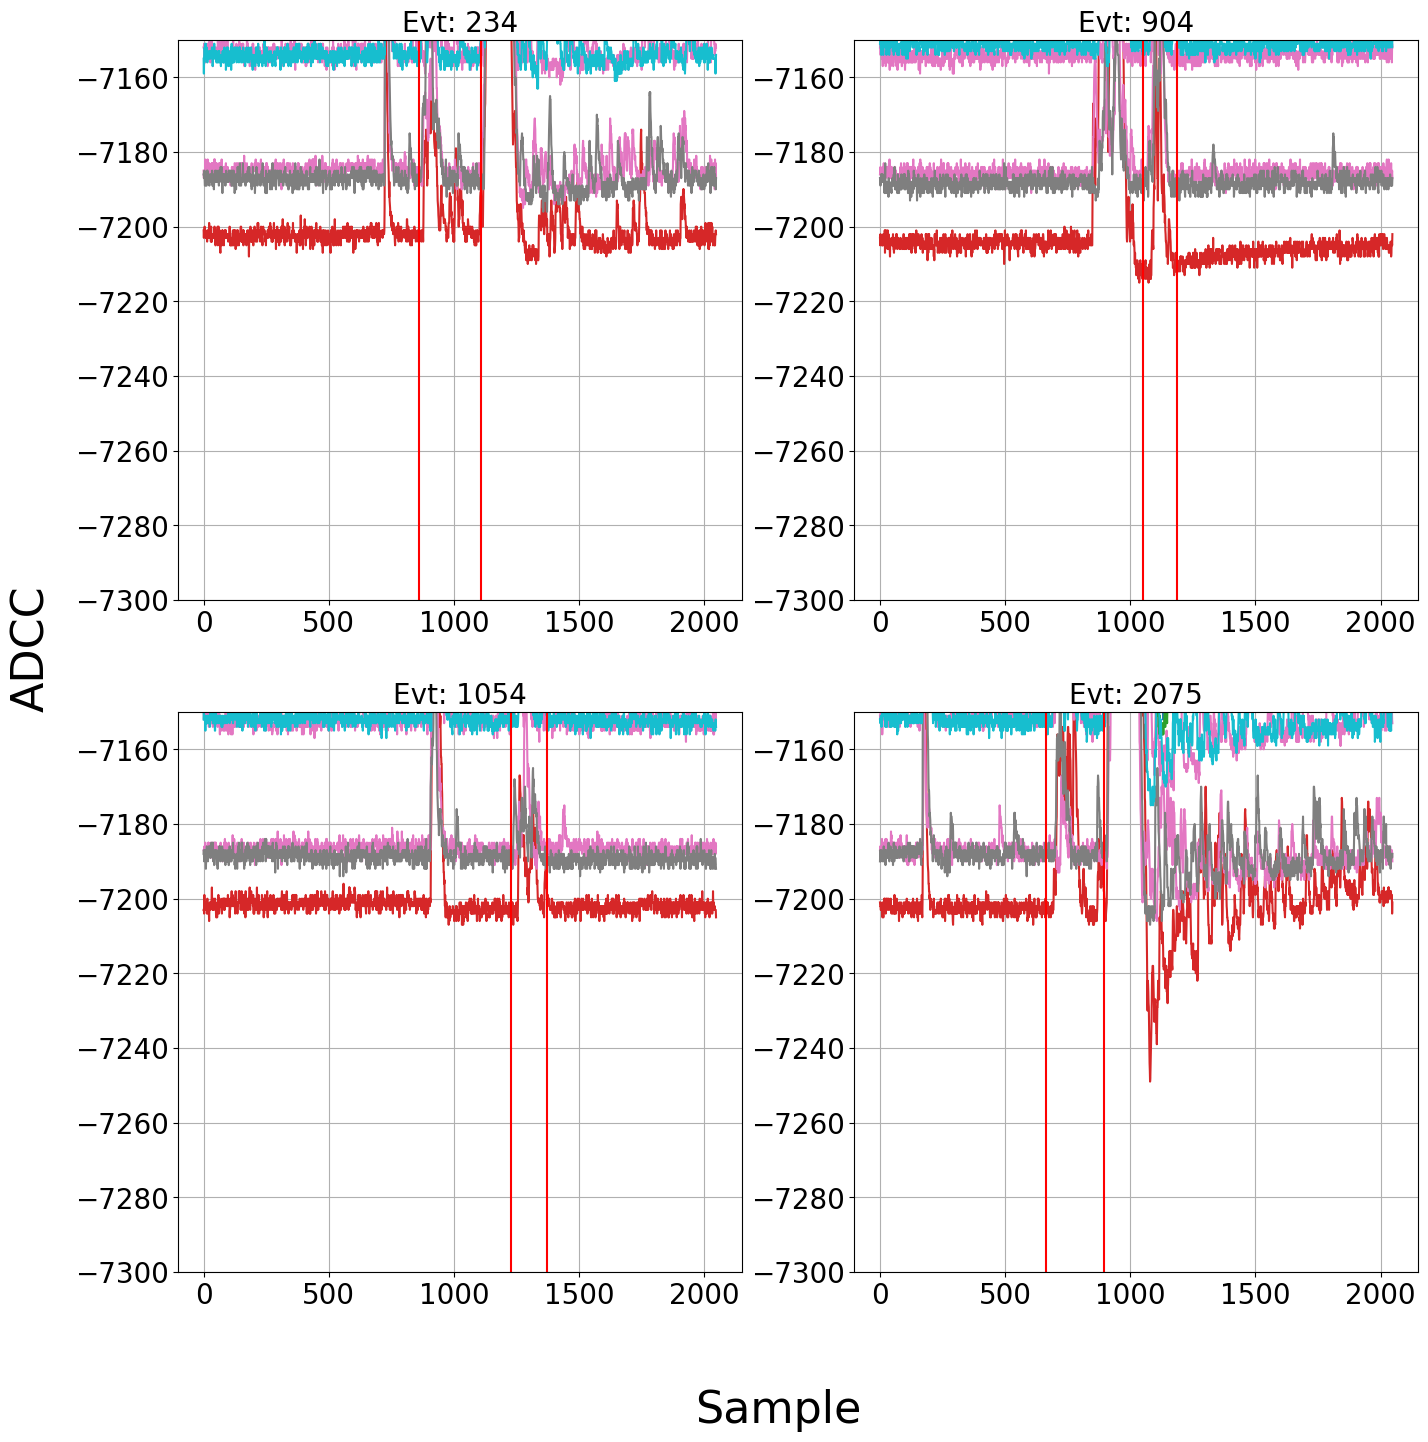

In [1131]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    j = i+0
    ax = axs.flatten()
    # Format: [cut_ch_eventids[ch][event]][:,cut_ch_pulseids[ch][event]]
    x0 = d_co['p_bnds'][cut_eventids[j]][:,cut_pulseids[j]][0]
    x1 = d_co['p_bnds'][cut_eventids[j]][:,cut_pulseids[j]][1]
    # Format: waveforms_ba[cut_ch_eventids[ch][event]][ch]
    ax[i].plot(np.arange(0,2048,1), waveforms_co[cut_eventids[j]].T,'-')
    ax[i].axvline(x=x0, color='r')
    ax[i].axvline(x=x1, color='r')
    ax[i].set_title(f'Evt: {cut_eventids[j]}', fontsize=20)
    #ax[i].set_xlim(x0,x1)
    ax[i].set_ylim(-7300,-7150)
    ax[i].grid()
fig.supxlabel('Sample', fontsize=32)
fig.supylabel('ADCC', fontsize=32)
plt.savefig('Ch1BigPulses.png')
plt.show()